In [181]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

# Load both files and combine
df1 = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')
df2 = pd.read_csv('ecommerce_customer_data_large.csv')

df = pd.concat([df1, df2], ignore_index=True)
df.drop_duplicates(inplace=True)

print(" Both files loaded & merged")
print(f"File 1 : {df1.shape[0]:,} rows")
print(f"File 2 : {df2.shape[0]:,} rows")
print(f"Combined (after dedup): {df.shape[0]:,} rows")
df.head()

 Both files loaded & merged
File 1 : 250,000 rows
File 2 : 250,000 rows
Combined (after dedup): 500,000 rows


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [182]:
# Data Cleaning & Feature Engineering

# Parse datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Drop duplicate age column (Customer Age == Age)
df.drop(columns=['Customer Age'], inplace=True)
df.rename(columns={'Age': 'Customer_Age'}, inplace=True)

# Clean column names
df.columns = df.columns.str.replace(' ', '_')

# Fill Returns null → 0 (no return recorded = no return)
df['Returns'] = df['Returns'].fillna(0)

# Time features
df['Year']       = df['Purchase_Date'].dt.year
df['Month']      = df['Purchase_Date'].dt.month
df['Month_Name'] = df['Purchase_Date'].dt.strftime('%b')
df['Quarter']    = df['Purchase_Date'].dt.to_period('Q').astype(str)
df['DayOfWeek']  = df['Purchase_Date'].dt.day_name()
df['Hour']       = df['Purchase_Date'].dt.hour

# Revenue per unit
df['Revenue_Per_Unit'] = df['Total_Purchase_Amount'] / df['Quantity'].replace(0, np.nan)

# Age group
bins   = [0, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '55+']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels)

print(" Cleaning & Feature Engineering Done")
print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]}")
print(f"Date Range : {df['Purchase_Date'].min().date()} → {df['Purchase_Date'].max().date()}")
print(f"Nulls left : {df.isnull().sum().sum()}")
df[['Customer_ID','Purchase_Date','Product_Category','Total_Purchase_Amount',
    'Returns','Year','Age_Group','Revenue_Per_Unit']].head(3)

 Cleaning & Feature Engineering Done
Rows       : 500,000
Columns    : 20
Date Range : 2020-01-01 → 2023-09-15
Nulls left : 0


,Customer_ID,Purchase_Date,Product_Category,Total_Purchase_Amount,Returns,Year,Age_Group,Revenue_Per_Unit
0,46251,2020-09-08 09:38:32,Electronics,740,0.0,2020,36-45,246.666667
1,46251,2022-03-05 12:56:35,Home,2739,0.0,2022,36-45,684.750000
2,46251,2022-05-23 18:18:01,Home,3196,0.0,2022,36-45,1598.000000


In [184]:
# Core KPIs

total_revenue    = df['Total_Purchase_Amount'].sum()
total_orders     = len(df)
unique_customers = df['Customer_ID'].nunique()
aov              = total_revenue / total_orders
avg_quantity     = df['Quantity'].mean()
return_rate      = (df['Returns'] > 0).mean() * 100
churn_rate       = df.drop_duplicates('Customer_ID')['Churn'].mean() * 100
avg_age          = df['Customer_Age'].mean()

kpis = {
    ' Total Revenue'       : f"${total_revenue:,.0f}",
    ' Total Orders'        : f"{total_orders:,}",
    ' Unique Customers'    : f"{unique_customers:,}",
    ' Avg Order Value'     : f"${aov:,.2f}",
    ' Avg Quantity/Order'  : f"{avg_quantity:.2f}",
    '  Return Rate'        : f"{return_rate:.1f}%",
    '  Churn Rate'         : f"{churn_rate:.1f}%",
    ' Avg Customer Age'    : f"{avg_age:.0f} yrs",
}

print("         KEY PERFORMANCE INDICATORS")

for k, v in kpis.items():
    print(f"  {k:<32} {v}")

         KEY PERFORMANCE INDICATORS
   Total Revenue                   $1,362,688,982
   Total Orders                    500,000
   Unique Customers                49,998
   Avg Order Value                 $2,725.38
   Avg Quantity/Order              3.00
    Return Rate                    40.4%
    Churn Rate                     20.0%
   Avg Customer Age                44 yrs


In [185]:
# RFM Segmentation

snapshot_date = df['Purchase_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_ID').agg(
    Recency   = ('Purchase_Date', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Purchase_Date', 'count'),
    Monetary  = ('Total_Purchase_Amount', 'sum')
).reset_index()

# Score each dimension 1–5
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment label
def rfm_label(row):
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['RFM_Score'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 7:
        return 'Potential Loyalists'
    elif row['RFM_Score'] >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(rfm_label, axis=1)

print(" RFM Segmentation Done")
print(f"\nSegment Distribution:")
print(rfm['Segment'].value_counts().to_string())
print(f"\nRFM Summary:")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1).to_string())

 RFM Segmentation Done

Segment Distribution:
Segment
Potential Loyalists    14208
Loyal Customers        14012
Champions               8873
At Risk                 7285
Lost                    5620

RFM Summary:
                     Recency  Frequency  Monetary
Segment                                          
At Risk                189.4        7.4   19121.8
Champions               40.8       14.0   39615.0
Lost                   338.2        5.7   14721.4
Loyal Customers         97.2       11.5   31856.5
Potential Loyalists    129.2        9.0   24125.5


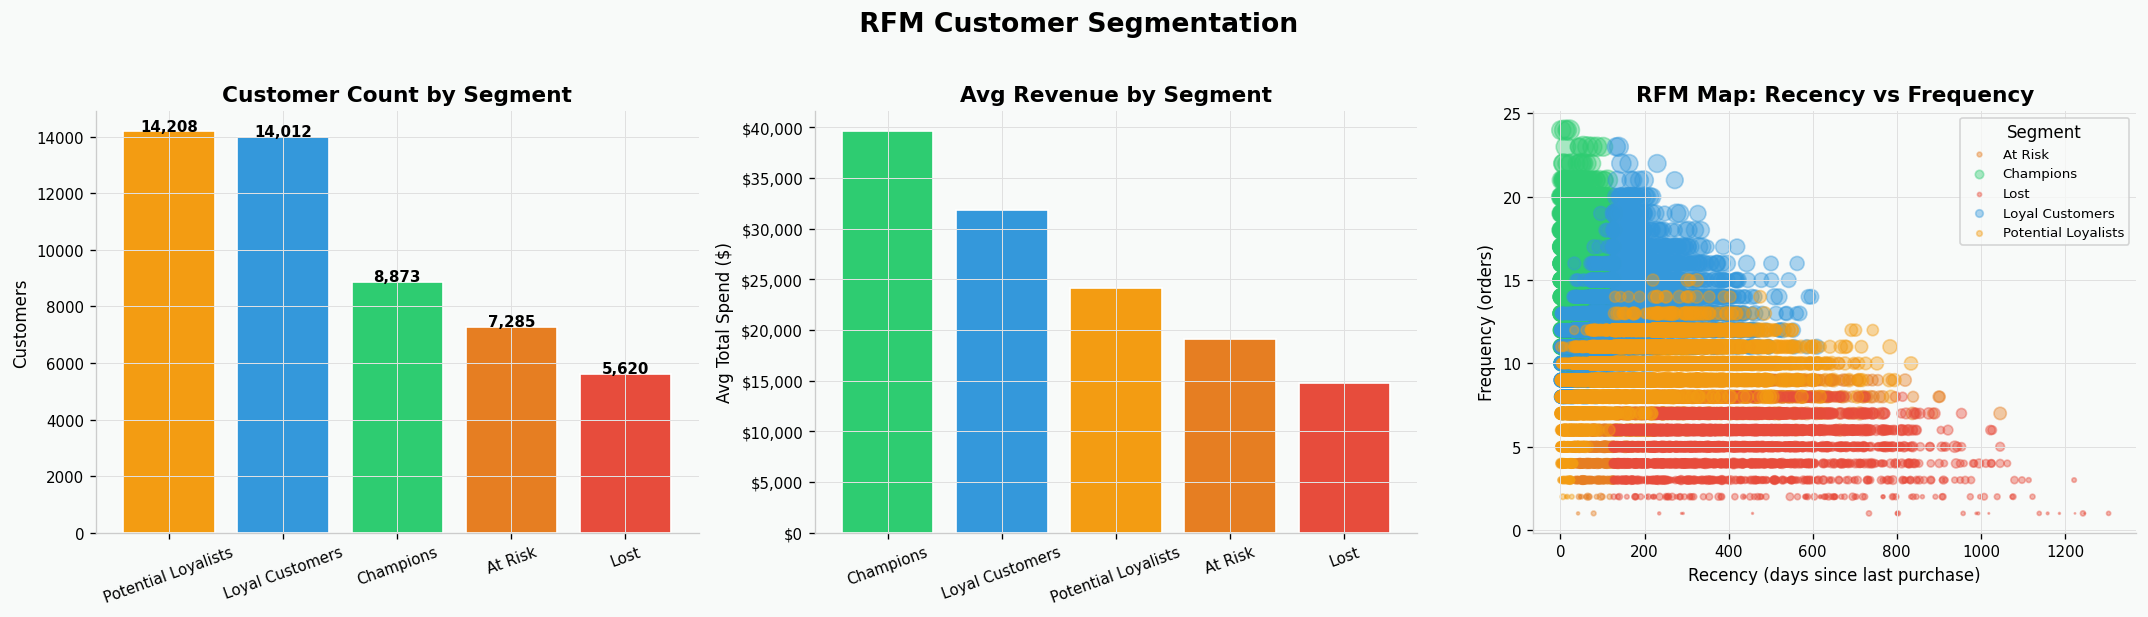

In [186]:
# RFM Segment Visualization

seg_counts = rfm['Segment'].value_counts()
seg_stats  = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)

seg_colors = {
    'Champions'          : '#2ecc71',
    'Loyal Customers'    : '#3498db',
    'Potential Loyalists': '#f39c12',
    'At Risk'            : '#e67e22',
    'Lost'               : '#e74c3c',
}
colors = [seg_colors[s] for s in seg_counts.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Segment sizes
bars = axes[0].bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Customer Count by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, seg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# ── Avg Monetary by segment
mon = seg_stats['Monetary'].sort_values(ascending=False)
axes[1].bar(mon.index, mon.values,
            color=[seg_colors[s] for s in mon.index], edgecolor='white')
axes[1].set_title('Avg Revenue by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Total Spend ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=20)

# ── RFM Bubble: Recency vs Frequency, size = Monetary
for seg, grp in rfm.groupby('Segment'):
    axes[2].scatter(grp['Recency'], grp['Frequency'],
                    s=grp['Monetary']/500, alpha=0.4,
                    label=seg, color=seg_colors[seg])
axes[2].set_title('RFM Map: Recency vs Frequency', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recency (days since last purchase)')
axes[2].set_ylabel('Frequency (orders)')
axes[2].legend(title='Segment', fontsize=8, markerscale=0.5)

plt.suptitle(' RFM Customer Segmentation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

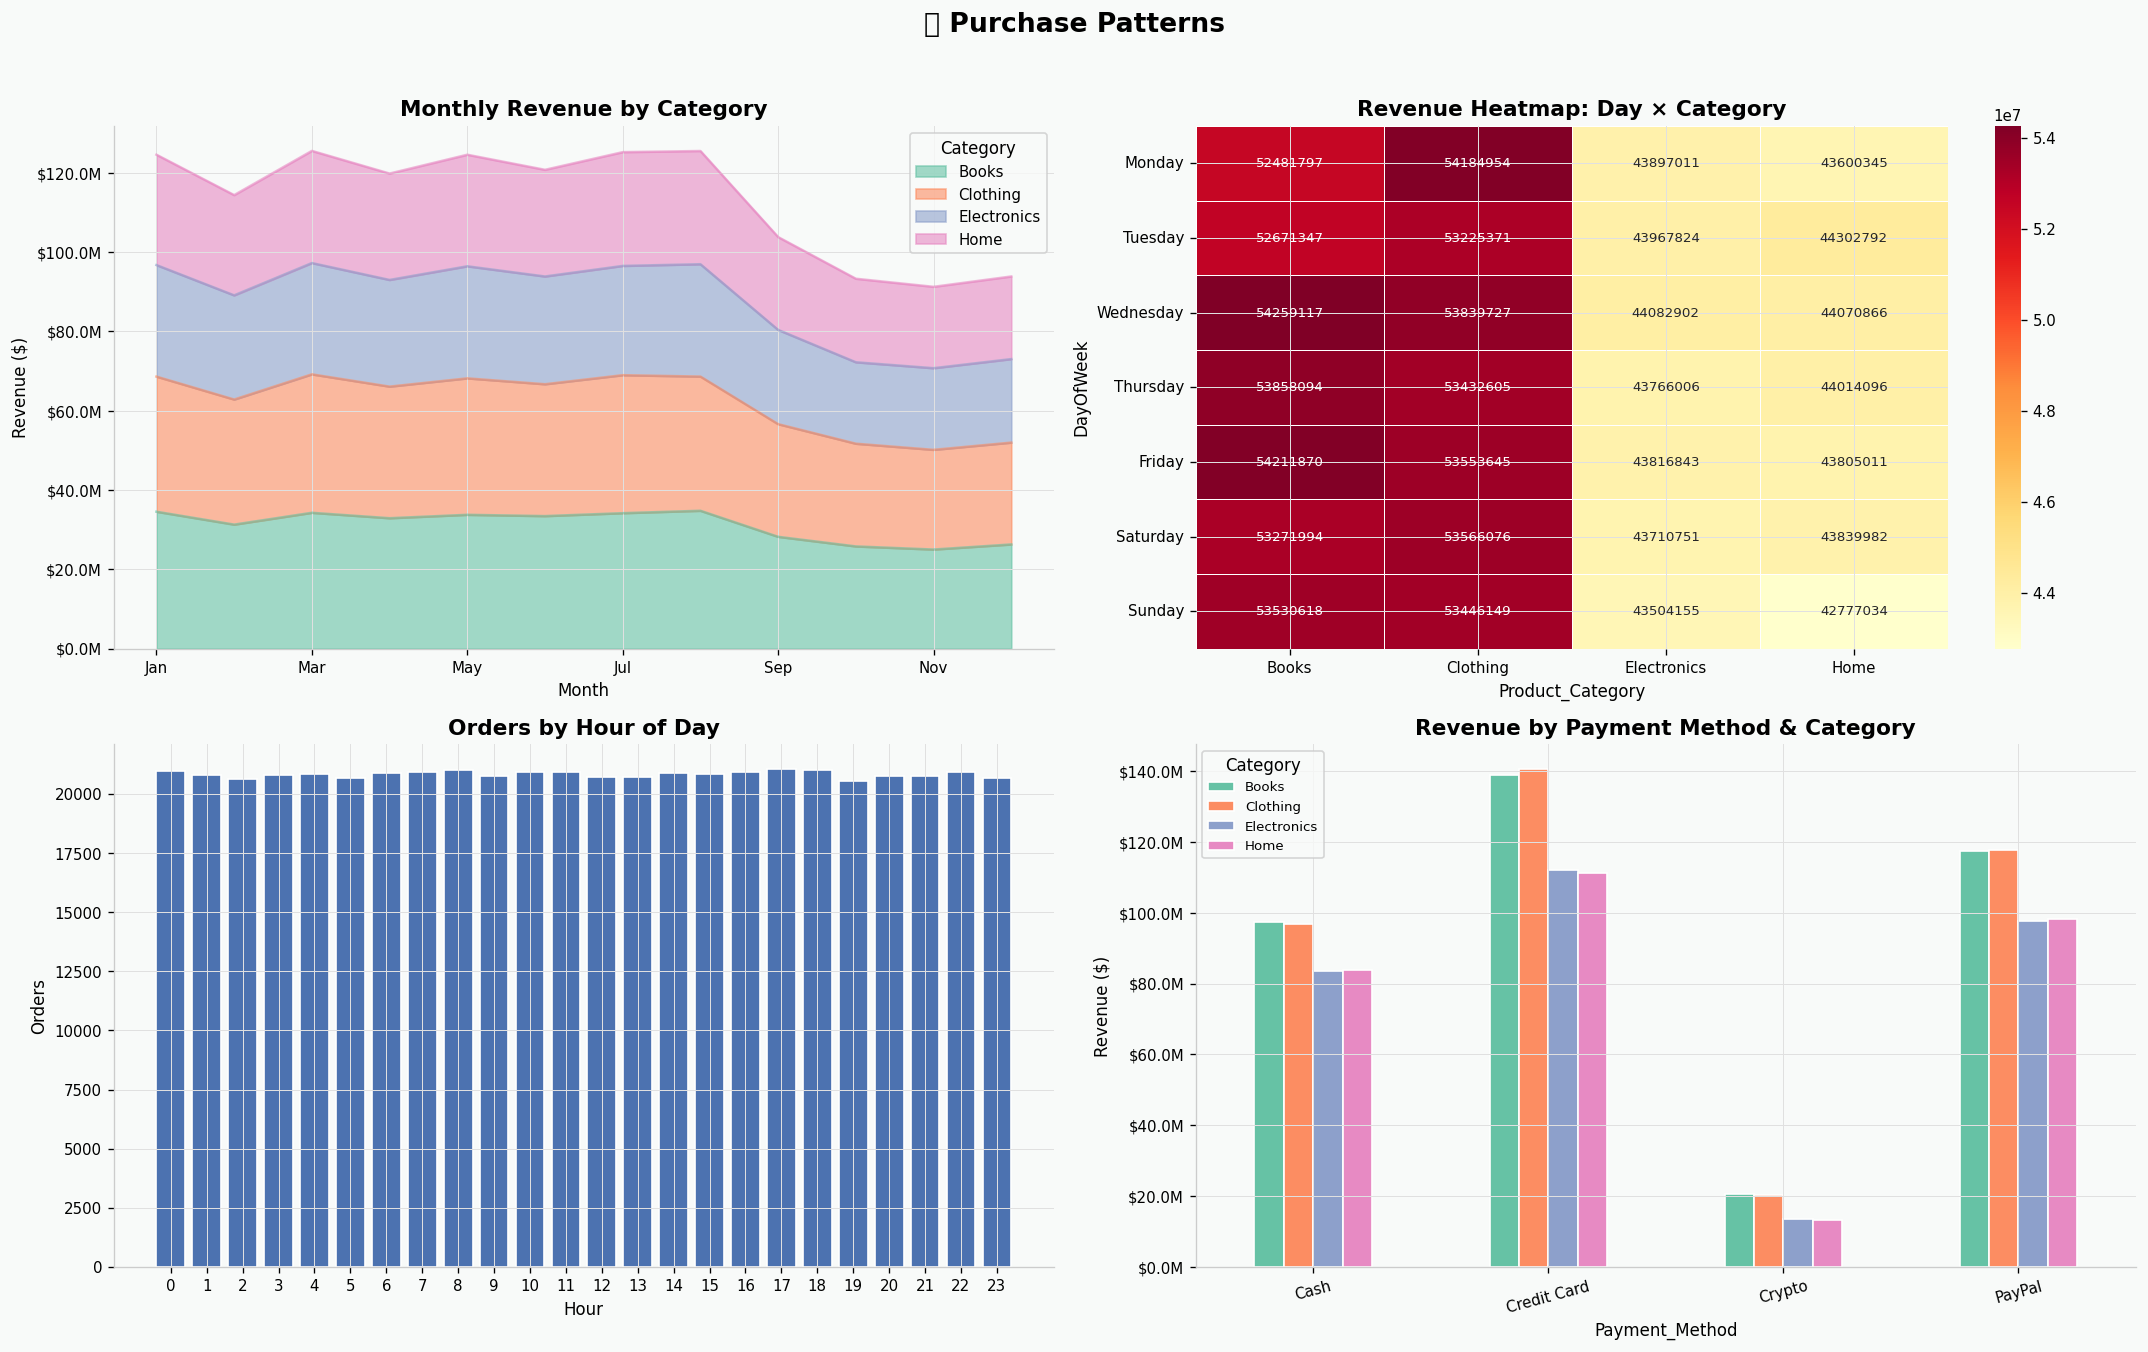

In [187]:
# Purchase Patterns

month_order  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
day_order    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

monthly_cat = (df.groupby(['Month_Name','Product_Category'])['Total_Purchase_Amount']
                 .sum().reset_index())
monthly_cat['Month_Name'] = pd.Categorical(monthly_cat['Month_Name'],
                                            categories=month_order, ordered=True)
monthly_cat = monthly_cat.sort_values('Month_Name')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# ── Monthly revenue by category
pivot_mc = monthly_cat.pivot(index='Month_Name', columns='Product_Category',
                              values='Total_Purchase_Amount').fillna(0)
pivot_mc.plot(kind='area', ax=axes[0][0], alpha=0.6,
              color=sns.color_palette("Set2", 4))
axes[0][0].set_title('Monthly Revenue by Category', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Month')
axes[0][0].set_ylabel('Revenue ($)')
axes[0][0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0][0].legend(title='Category')

# ── Day of week heatmap: category × day
dow_cat = df.groupby(['DayOfWeek','Product_Category'])['Total_Purchase_Amount'].sum().unstack().fillna(0)
dow_cat = dow_cat.reindex(day_order)
sns.heatmap(dow_cat, ax=axes[0][1], annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, annot_kws={'size': 8})
axes[0][1].set_title('Revenue Heatmap: Day × Category', fontsize=13, fontweight='bold')

# ── Hour of day distribution
hour_data = df.groupby('Hour').size().reset_index(name='orders')
axes[1][0].bar(hour_data['Hour'], hour_data['orders'],
               color='#4C72B0', edgecolor='white')
axes[1][0].set_title('Orders by Hour of Day', fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Hour')
axes[1][0].set_ylabel('Orders')
axes[1][0].set_xticks(range(0, 24))

# ── Payment method breakdown
pay_cat = (df.groupby(['Payment_Method','Product_Category'])['Total_Purchase_Amount']
             .sum().unstack().fillna(0))
pay_cat.plot(kind='bar', ax=axes[1][1], color=sns.color_palette("Set2", 4),
             edgecolor='white')
axes[1][1].set_title('Revenue by Payment Method & Category', fontsize=13, fontweight='bold')
axes[1][1].set_ylabel('Revenue ($)')
axes[1][1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1][1].tick_params(axis='x', rotation=15)
axes[1][1].legend(title='Category', fontsize=8)

plt.suptitle('🛒 Purchase Patterns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

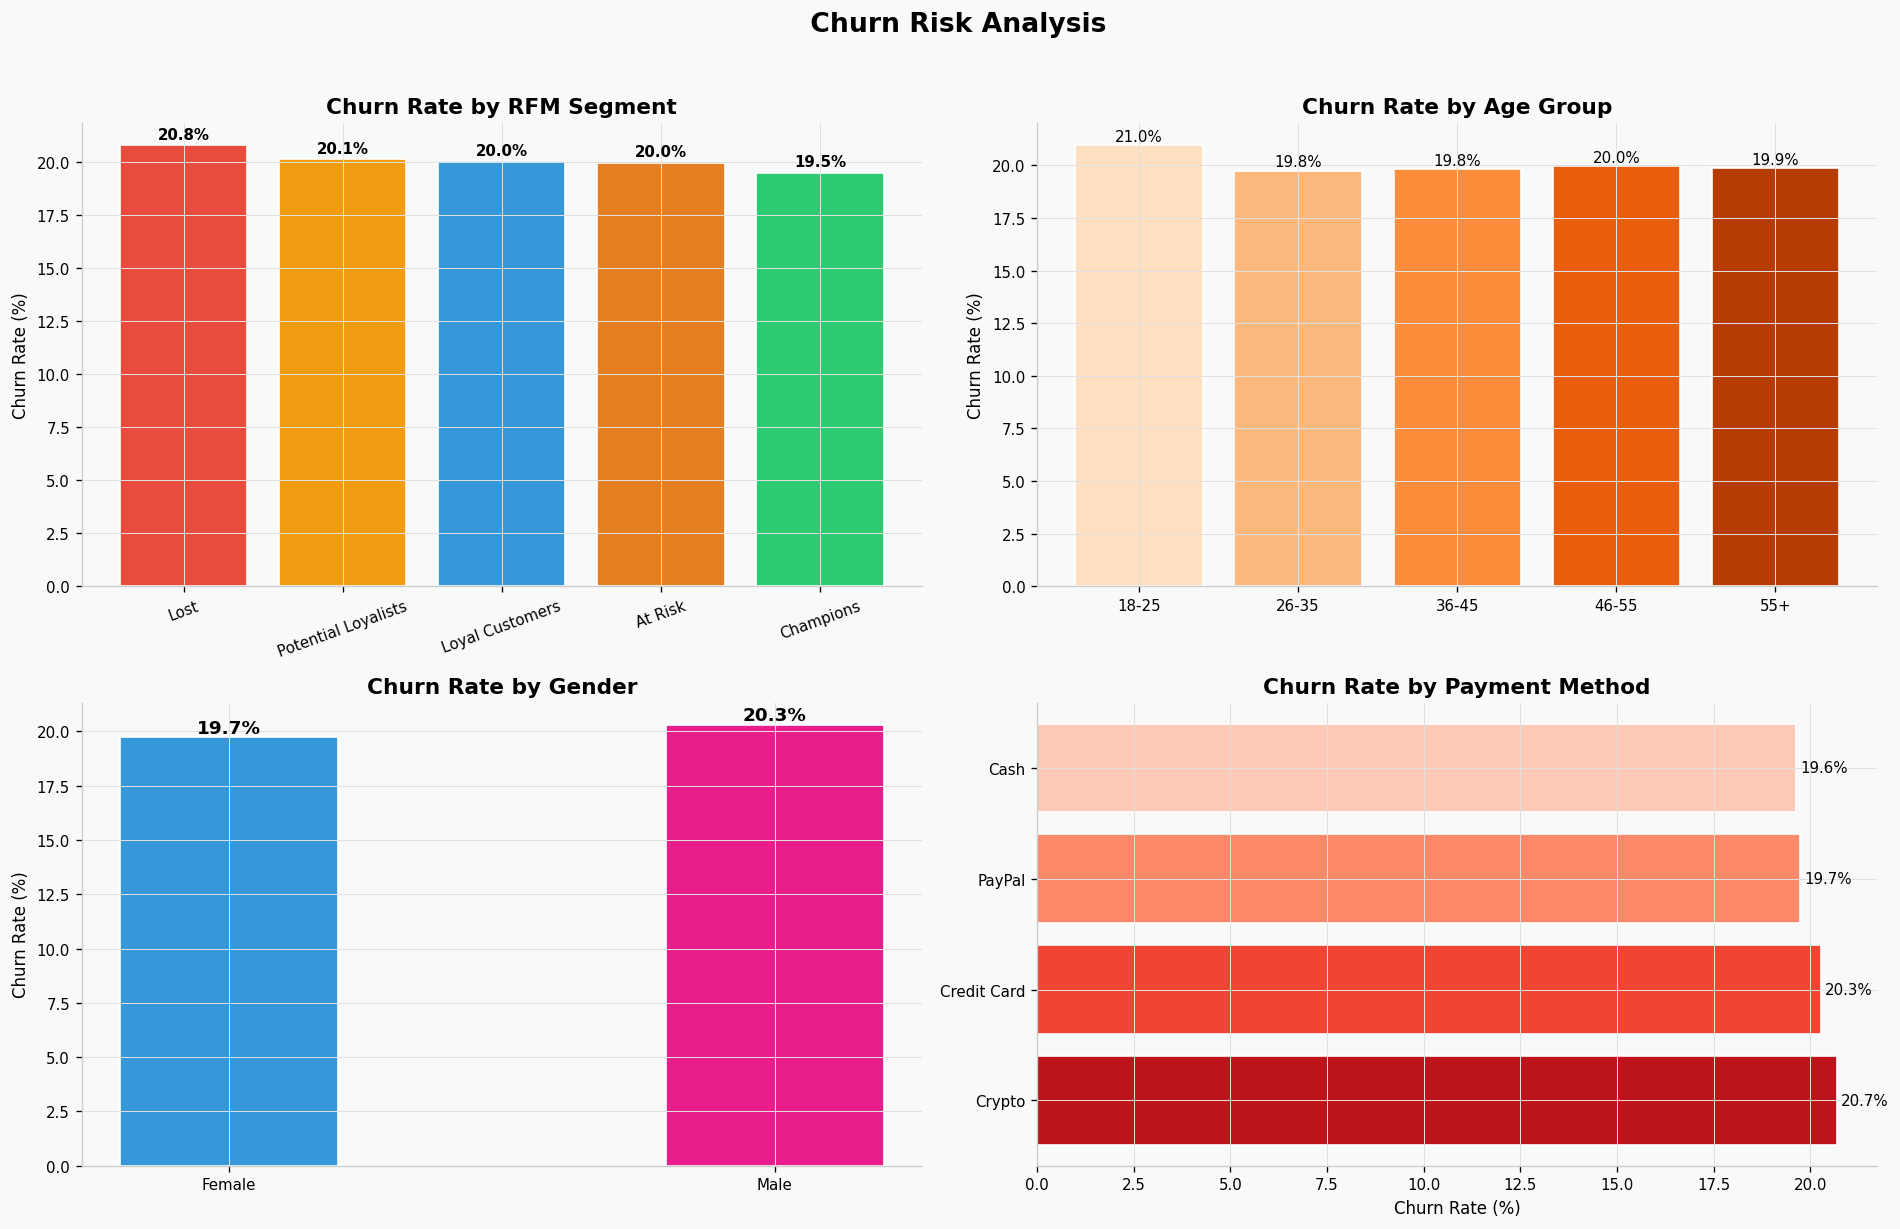

In [188]:
# Churn Analysis

cust_df = df.drop_duplicates('Customer_ID')[['Customer_ID','Churn','Gender',
                                              'Customer_Age','Age_Group','Payment_Method']]
# Attach RFM segment
cust_df = cust_df.merge(rfm[['Customer_ID','Segment','Recency','Frequency','Monetary']],
                         on='Customer_ID', how='left')

churn_seg     = cust_df.groupby('Segment')['Churn'].mean().sort_values(ascending=False) * 100
churn_age     = cust_df.groupby('Age_Group')['Churn'].mean() * 100
churn_gender  = cust_df.groupby('Gender')['Churn'].mean() * 100
churn_pay     = cust_df.groupby('Payment_Method')['Churn'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Churn by segment
seg_colors_list = [seg_colors.get(s, '#999') for s in churn_seg.index]
bars = axes[0][0].bar(churn_seg.index, churn_seg.values, color=seg_colors_list, edgecolor='white')
axes[0][0].set_title('Churn Rate by RFM Segment', fontsize=13, fontweight='bold')
axes[0][0].set_ylabel('Churn Rate (%)')
axes[0][0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, churn_seg.values):
    axes[0][0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Churn by age group
axes[0][1].bar(churn_age.index.astype(str), churn_age.values,
               color=sns.color_palette("Oranges", len(churn_age)), edgecolor='white')
axes[0][1].set_title('Churn Rate by Age Group', fontsize=13, fontweight='bold')
axes[0][1].set_ylabel('Churn Rate (%)')
for i, val in enumerate(churn_age.values):
    axes[0][1].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=9)

# ── Churn by gender
axes[1][0].bar(churn_gender.index, churn_gender.values,
               color=['#3498db','#e91e8c'], edgecolor='white', width=0.4)
axes[1][0].set_title('Churn Rate by Gender', fontsize=13, fontweight='bold')
axes[1][0].set_ylabel('Churn Rate (%)')
for i, val in enumerate(churn_gender.values):
    axes[1][0].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# ── Churn by payment method
axes[1][1].barh(churn_pay.index, churn_pay.values,
                color=sns.color_palette("Reds_r", len(churn_pay)), edgecolor='white')
axes[1][1].set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Churn Rate (%)')
for i, val in enumerate(churn_pay.values):
    axes[1][1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle(' Churn Risk Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

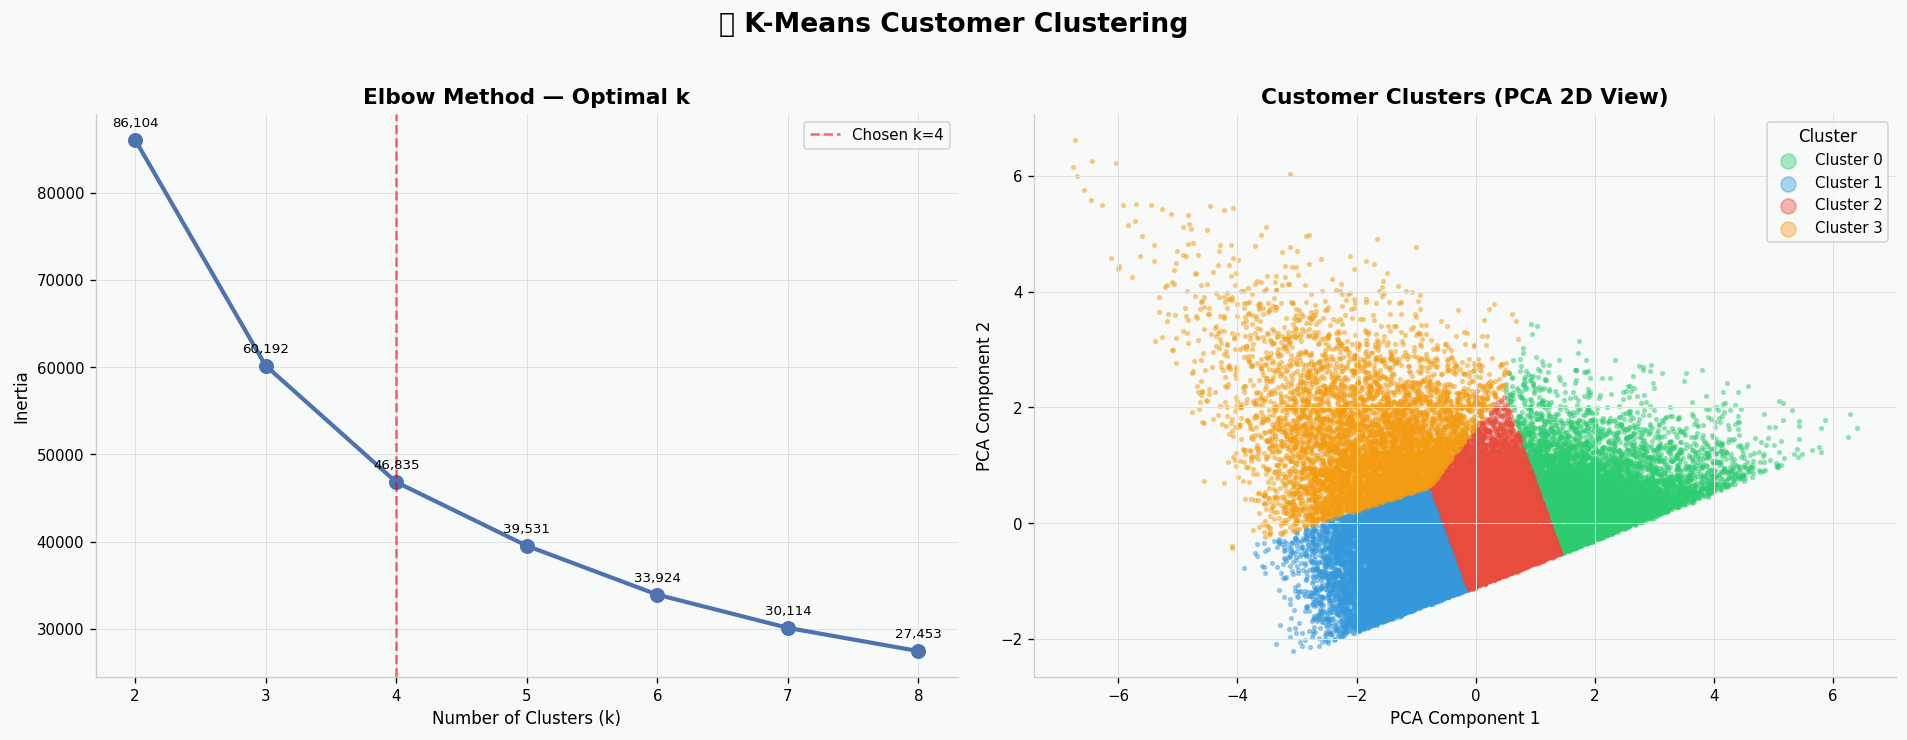


Cluster Profiles:
         Recency  Frequency  Monetary
Cluster                              
0           86.2       14.5   41287.0
1          105.2        7.1   18304.9
2           98.8       10.7   29087.9
3          414.8        7.3   19702.5


In [189]:
# K-Means Clustering (on RFM)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

rfm_features = rfm[['Recency','Frequency','Monetary']].copy()
scaler       = StandardScaler()
rfm_scaled   = scaler.fit_transform(rfm_features)

# Elbow method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

# Final model with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# PCA for 2D plotting
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Elbow curve
axes[0].plot(K_range, inertias, marker='o', linewidth=2.5, color='#4C72B0', markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Chosen k=4')
axes[0].set_title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()
for k, ine in zip(K_range, inertias):
    axes[0].annotate(f'{ine:,.0f}', (k, ine),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)

# ── PCA cluster scatter
cluster_colors = ['#2ecc71','#3498db','#e74c3c','#f39c12']
for c in sorted(rfm['Cluster'].unique()):
    grp = rfm[rfm['Cluster'] == c]
    axes[1].scatter(grp['PCA1'], grp['PCA2'], s=5, alpha=0.4,
                    color=cluster_colors[c], label=f'Cluster {c}')
axes[1].set_title('Customer Clusters (PCA 2D View)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].legend(title='Cluster', markerscale=4)

plt.suptitle('🔵 K-Means Customer Clustering', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCluster Profiles:")
print(rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1).to_string())

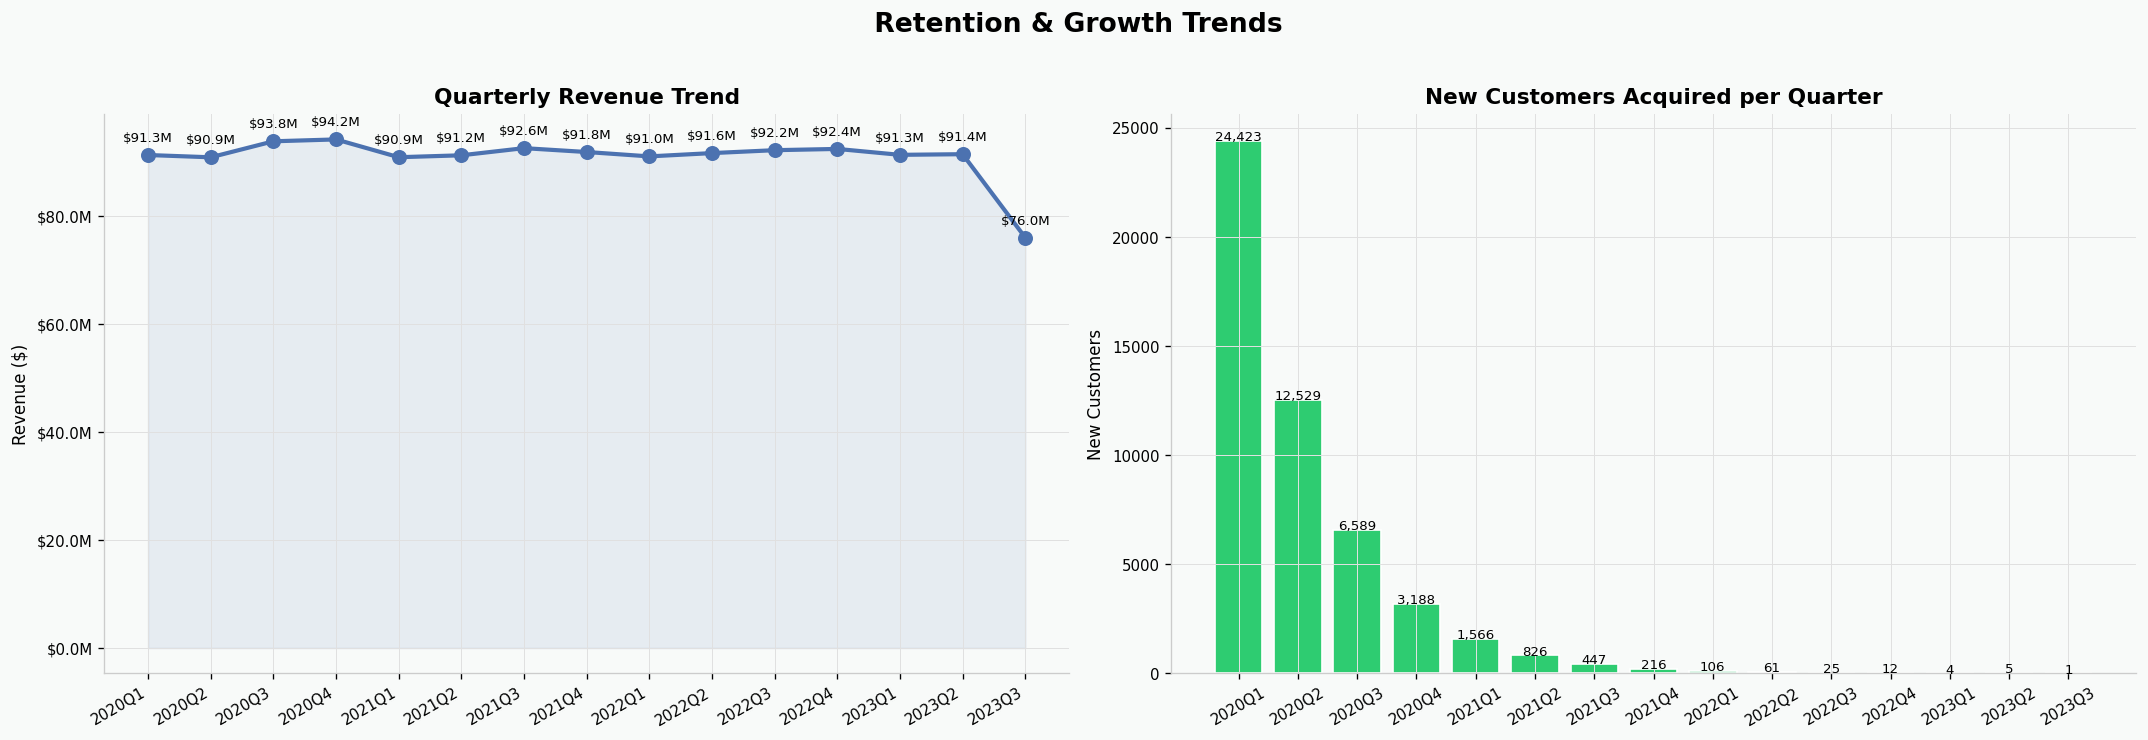

In [190]:
# Retention Trend Over Time

# Monthly cohort: first purchase month per customer
first_purchase = df.groupby('Customer_ID')['Purchase_Date'].min().reset_index()
first_purchase.columns = ['Customer_ID', 'First_Purchase']
first_purchase['Cohort'] = first_purchase['First_Purchase'].dt.to_period('Q').astype(str)

df2 = df.merge(first_purchase[['Customer_ID','Cohort']], on='Customer_ID')
df2['Purchase_Quarter'] = df2['Purchase_Date'].dt.to_period('Q').astype(str)

# Revenue over time
revenue_trend = df.groupby('Quarter')['Total_Purchase_Amount'].sum().reset_index()
new_vs_ret    = df2.groupby(['Purchase_Quarter','Cohort']).agg(
    Revenue=('Total_Purchase_Amount','sum')).reset_index()

# New customer count per quarter
new_custs = first_purchase.groupby('Cohort').size().reset_index(name='New_Customers')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Quarterly revenue trend
axes[0].plot(revenue_trend['Quarter'], revenue_trend['Total_Purchase_Amount'],
             marker='o', linewidth=2.5, color='#4C72B0', markersize=8)
axes[0].fill_between(range(len(revenue_trend)),
                     revenue_trend['Total_Purchase_Amount'], alpha=0.1, color='#4C72B0')
axes[0].set_xticks(range(len(revenue_trend)))
axes[0].set_xticklabels(revenue_trend['Quarter'], rotation=30, ha='right')
axes[0].set_title('Quarterly Revenue Trend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for i, row in revenue_trend.iterrows():
    axes[0].annotate(f"${row['Total_Purchase_Amount']/1e6:.1f}M",
                     (i, row['Total_Purchase_Amount']),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)

# ── New customers per quarter
axes[1].bar(new_custs['Cohort'], new_custs['New_Customers'],
            color='#2ecc71', edgecolor='white')
axes[1].set_title('New Customers Acquired per Quarter', fontsize=13, fontweight='bold')
axes[1].set_ylabel('New Customers')
axes[1].tick_params(axis='x', rotation=30)
for i, row in new_custs.iterrows():
    axes[1].text(i, row['New_Customers'] + 10, f"{row['New_Customers']:,}",
                 ha='center', fontsize=8)

plt.suptitle(' Retention & Growth Trends', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

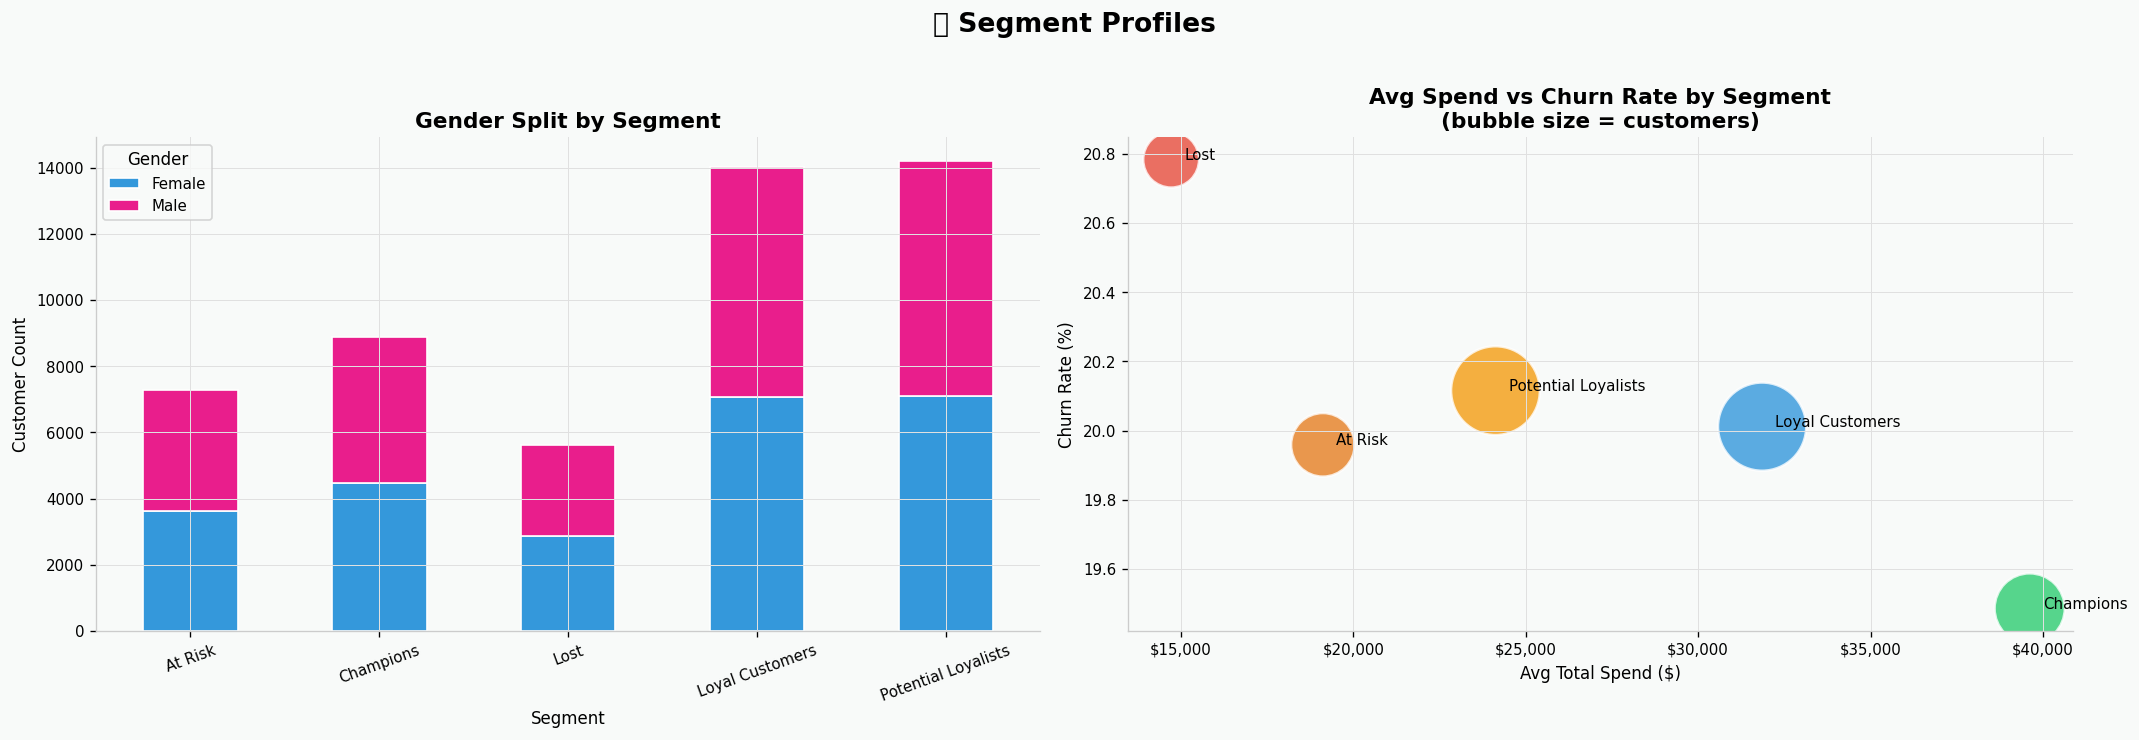


            FINAL SEGMENT PROFILE SUMMARY
            Segment  Customers Churn_Rate  Avg_Recency  Avg_Freq  Avg_Spend
            At Risk       7285      20.0%        189.4       7.4    19121.8
          Champions       8873      19.5%         40.8      14.0    39615.0
               Lost       5620      20.8%        338.2       5.7    14721.4
    Loyal Customers      14012      20.0%         97.2      11.5    31856.5
Potential Loyalists      14208      20.1%        129.2       9.0    24125.5

 Analysis Complete | 49,998 customers | $1,362,688,982 total revenue


In [191]:
# Segment Profiles & Final Summary

# Full segment profile
seg_profile = cust_df.groupby('Segment').agg(
    Customers    = ('Customer_ID', 'count'),
    Churn_Rate   = ('Churn', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Recency  = ('Recency', 'mean'),
    Avg_Freq     = ('Frequency', 'mean'),
    Avg_Spend    = ('Monetary', 'mean'),
).round(1).reset_index()

# Gender split per segment
gen_seg = cust_df.groupby(['Segment','Gender']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Stacked gender bar per segment
gen_seg.plot(kind='bar', stacked=True, ax=axes[0],
             color=['#3498db','#e91e8c'], edgecolor='white')
axes[0].set_title('Gender Split by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Gender')

# ── Avg spend vs churn rate bubble
seg_bubble = cust_df.groupby('Segment').agg(
    Avg_Spend  = ('Monetary', 'mean'),
    Churn_Rate = ('Churn', 'mean'),
    Count      = ('Customer_ID', 'count')
).reset_index()

colors_b = [seg_colors.get(s, '#999') for s in seg_bubble['Segment']]
sc = axes[1].scatter(seg_bubble['Avg_Spend'], seg_bubble['Churn_Rate']*100,
                     s=seg_bubble['Count']/5, color=colors_b, alpha=0.8, edgecolors='white', linewidth=1.5)
for _, row in seg_bubble.iterrows():
    axes[1].annotate(row['Segment'],
                     (row['Avg_Spend'], row['Churn_Rate']*100),
                     textcoords="offset points", xytext=(8, 0), fontsize=9)
axes[1].set_title('Avg Spend vs Churn Rate by Segment\n(bubble size = customers)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Total Spend ($)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('👥 Segment Profiles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print("            FINAL SEGMENT PROFILE SUMMARY")
print("=" * 65)
print(seg_profile.to_string(index=False))
print("=" * 65)
print(f"\n Analysis Complete | {df['Customer_ID'].nunique():,} customers | "
      f"${df['Total_Purchase_Amount'].sum():,.0f} total revenue")